In [2]:
from google.colab import files
uploaded = files.upload()

Saving Fashion_Retail_Sales.csv to Fashion_Retail_Sales.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
FR = pd.read_csv("Fashion_Retail_Sales.csv")

In [5]:
FR.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash


In [6]:
FR.tail()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
3395,4118,Shorts,37.0,09-07-2023,2.7,Cash
3396,4056,Slippers,176.0,16-03-2023,2.5,Cash
3397,3991,Onesie,NaN,03-10-2022,2.4,Credit Card
3398,4042,Sandals,128.0,01-01-2023,1.8,Cash
3399,4001,Backpack,115.0,22-03-2023,1.4,Cash


In [7]:
FR.describe()

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,2750.000000,3076.000000
mean,4039.660588,156.709818,2.999057
std,48.122583,419.536669,1.156505
min,3957.000000,10.000000,1.000000
25%,3997.000000,57.000000,2.000000
50%,4040.000000,110.000000,3.000000
75%,4081.000000,155.750000,4.000000
max,4122.000000,4932.000000,5.000000


In [8]:
FR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB


In [9]:
FR.isnull().sum()

,0
Customer Reference ID,0
Item Purchased,0
Purchase Amount (USD),650
Date Purchase,0
Review Rating,324
Payment Method,0


In [10]:
FR.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
3395,False
3396,False
3397,False
3398,False


In [11]:
FR.shape

(3400, 6)

In [12]:
FR.columns

Index(['Customer Reference ID', 'Item Purchased', 'Purchase Amount (USD)',
       'Date Purchase', 'Review Rating', 'Payment Method'],
      dtype='object')

<Axes: xlabel='Purchase Amount (USD)', ylabel='Count'>

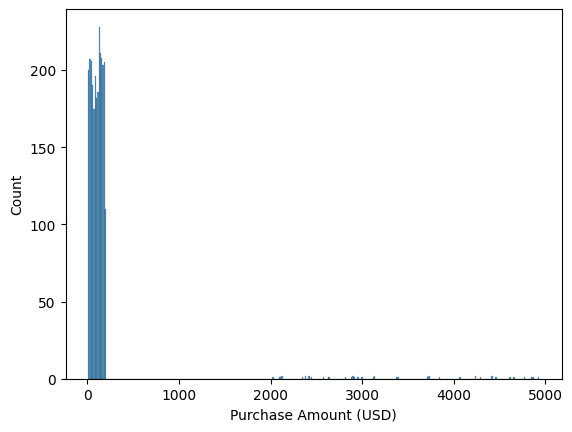

In [14]:
# Histogram on Purchase Amount
sns.histplot(FR['Purchase Amount (USD)'])

<Axes: xlabel='count', ylabel='Payment Method'>

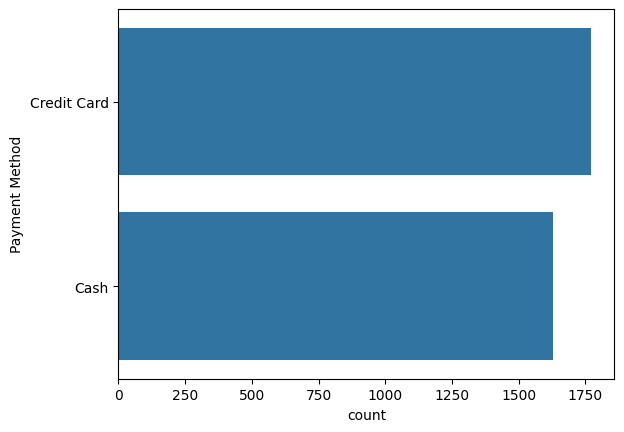

In [15]:
# Count plot on payment methods
sns.countplot(FR['Payment Method'])

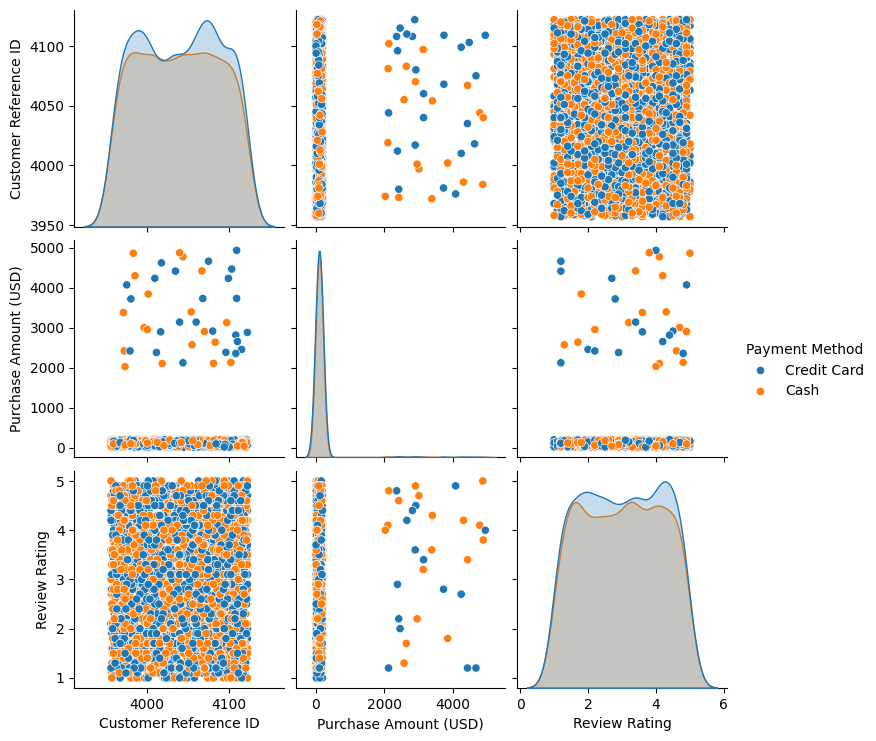

In [16]:
# Pair plot on payment method todetect outliers
sns.pairplot(FR, hue = 'Payment Method')

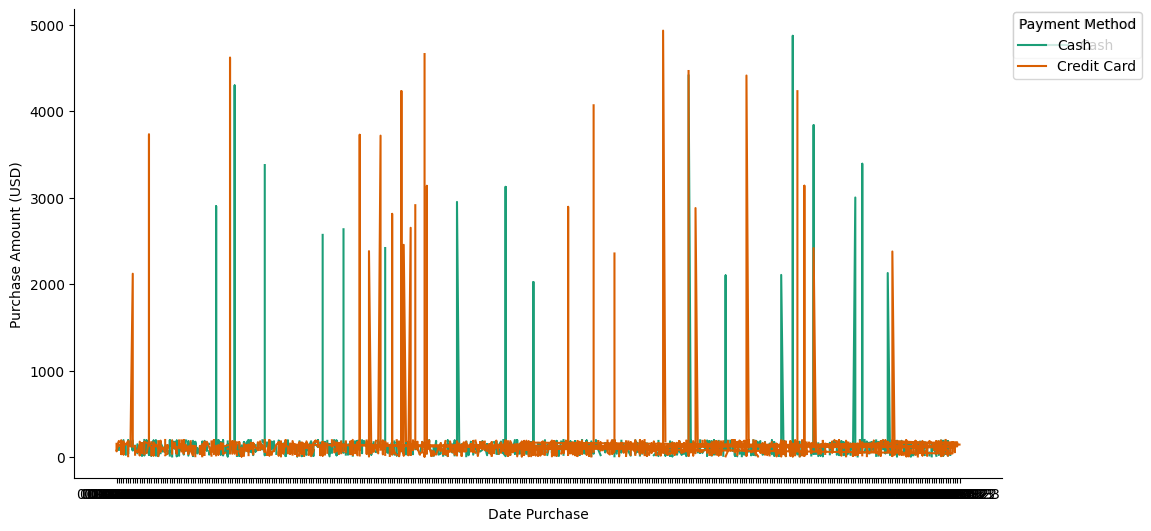

In [27]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date Purchase']
  ys = series['Purchase Amount (USD)']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = FR.sort_values('Date Purchase', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Payment Method')):
  _plot_series(series, series_name, i)
  fig.legend(title='Payment Method', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date Purchase')
_ = plt.ylabel('Purchase Amount (USD)')

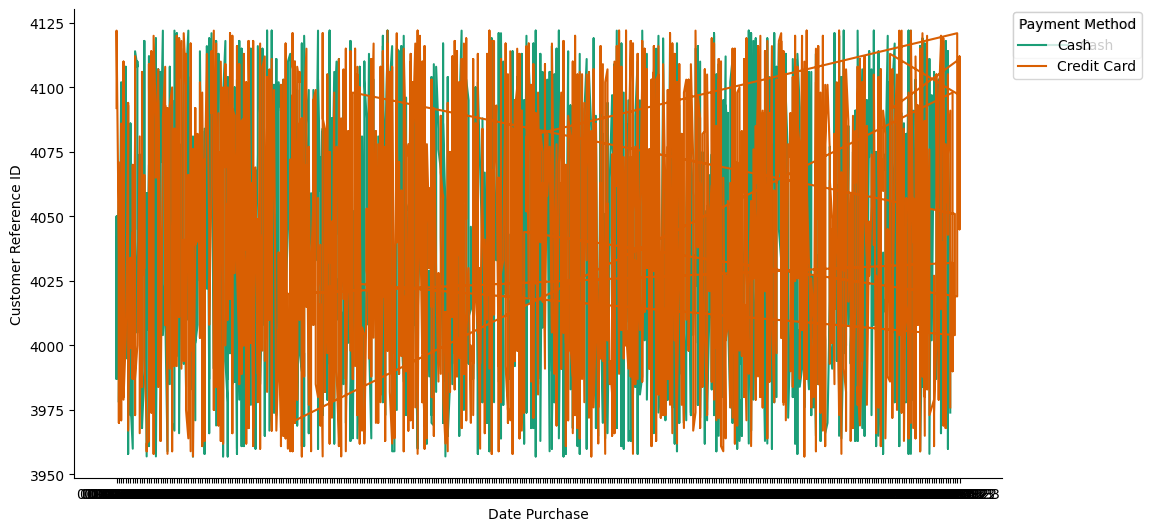

In [24]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date Purchase']
  ys = series['Customer Reference ID']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = FR.sort_values('Date Purchase', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Payment Method')):
  _plot_series(series, series_name, i)
  fig.legend(title='Payment Method', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date Purchase')
_ = plt.ylabel('Customer Reference ID')

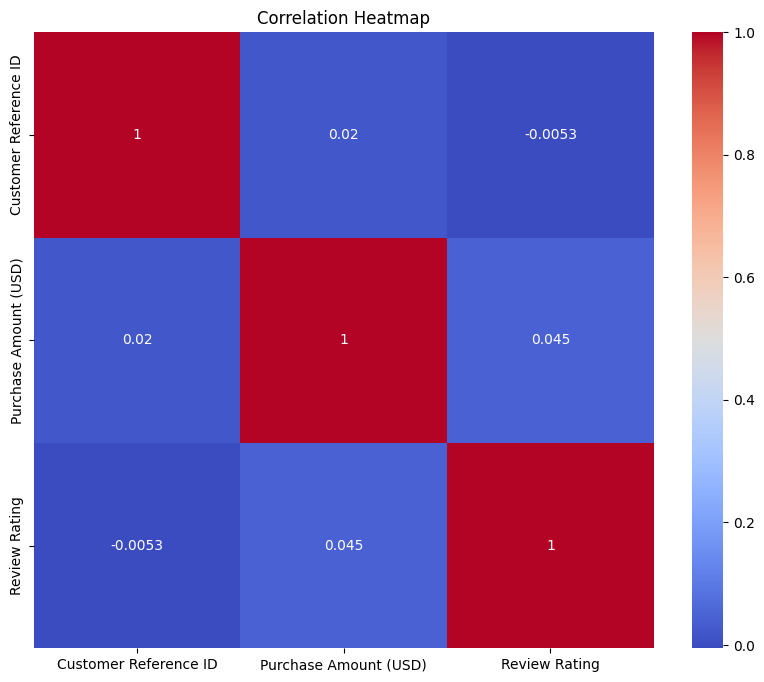

In [21]:
if FR.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    # Select only numeric columns for correlation calculation
    numeric_FR = FR.select_dtypes(include=np.number)
    corr = numeric_FR.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print('Skipping correlation heatmap as there are fewer than four numeric columns.')